In [2]:
import io
import gzip
import requests
import numpy as np
import pandas as pd


BUOYS = [
    "42001",
    "42002",
    "42003",
    "42012",
    "42019",
    "42020",
    "42036",
    "42039",
    "42040",
    "42096",
    "42098"
]

START = "2024-09-24"
END   = "2024-09-28"


def _parse_ndbc_stdmet_text(text: str) -> pd.DataFrame:
    """
    Parse one NDBC stdmet text file into a DataFrame.

    Handles common historical file variants, including headers like:
      #YY MM DD hh mm ...
    or
      YYYY MM DD hh mm ...
    """
    lines = text.splitlines()
    if not lines:
        raise ValueError("Empty file")

    # Remove blank lines
    lines = [ln.strip() for ln in lines if ln.strip()]
    if not lines:
        raise ValueError("No nonblank lines")

    header_line = lines[0].lstrip("#").strip()
    cols = header_line.split()

    # Some files have a second units line; detect and skip it.
    data_start = 1
    if len(lines) > 1:
        second = lines[1].split()
        # If second line length matches header and mostly nonnumeric, treat as units row
        nonnumeric = 0
        for tok in second:
            try:
                float(tok)
            except Exception:
                nonnumeric += 1
        if len(second) == len(cols) and nonnumeric >= max(3, len(second) // 3):
            data_start = 2

    data_text = "\n".join(lines[data_start:])
    if not data_text.strip():
        return pd.DataFrame(columns=cols)

    df = pd.read_csv(
        io.StringIO(data_text),
        sep=r"\s+",
        names=cols,
        na_values=["MM", "999", "999.0", "9999", "99.0", "99.00", "99999", "999999"],
        engine="python",   # safer for irregular spacing
    )

    # Build datetime from whichever year column exists
    year_col = None
    for candidate in ["YYYY", "#YYYY", "YY", "#YY"]:
        if candidate in df.columns:
            year_col = candidate
            break

    if year_col is None:
        raise ValueError(f"Could not find year column in columns: {list(df.columns)}")

    required = ["MM", "DD", "hh"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Missing required time column: {c}")

    minute_col = "mm" if "mm" in df.columns else None

    year = df[year_col].astype(int).to_numpy()
    if "YY" in year_col:
        year = np.where(year < 100, 2000 + year, year)

    month = df["MM"].astype(int).to_numpy()
    day = df["DD"].astype(int).to_numpy()
    hour = df["hh"].astype(int).to_numpy()
    minute = df[minute_col].astype(int).to_numpy() if minute_col else np.zeros(len(df), dtype=int)

    dt = pd.to_datetime(
        {
            "year": year,
            "month": month,
            "day": day,
            "hour": hour,
            "minute": minute,
        },
        errors="coerce",
        utc=True,
    )

    df.insert(0, "time", dt)
    df = df.dropna(subset=["time"]).reset_index(drop=True)
    return df


def download_ndbc_stdmet_station_year(station: str, year: int = 2024, timeout: int = 60) -> pd.DataFrame:
    """
    Download and parse one NDBC historical stdmet file.
    """
    url = f"https://www.ndbc.noaa.gov/data/historical/stdmet/{station}h{year}.txt.gz"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()

    with gzip.GzipFile(fileobj=io.BytesIO(r.content)) as gz:
        text = gz.read().decode("utf-8", errors="replace")

    df = _parse_ndbc_stdmet_text(text)
    df["station"] = station
    return df


def subset_date_range_inclusive(
    df: pd.DataFrame,
    start: str,
    end: str,
    time_col: str = "time",
) -> pd.DataFrame:
    """
    Inclusive date filter on UTC timestamps.
    For end='2024-09-28', keeps all rows through 2024-09-28 23:59:59 UTC.
    """
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)

    out = df.loc[(df[time_col] >= start_ts) & (df[time_col] <= end_ts)].copy()
    return out


def download_ndbc_bulk_stats(
    buoys,
    start="2024-09-24",
    end="2024-09-28",
    year=2024,
):
    """
    Download NDBC bulk statistics for multiple buoys and return:
      combined_df, per_buoy_dict
    """
    per_buoy = {}

    for buoy in buoys:
        try:
            df = download_ndbc_stdmet_station_year(buoy, year=year)
            df = subset_date_range_inclusive(df, start=start, end=end)
            per_buoy[buoy] = df
            print(f"{buoy}: {len(df)} records")
        except Exception as e:
            print(f"{buoy}: FAILED -> {e}")
            per_buoy[buoy] = pd.DataFrame()

    combined = pd.concat(
        [df for df in per_buoy.values() if len(df) > 0],
        ignore_index=True,
        sort=False,
    ) if any(len(df) > 0 for df in per_buoy.values()) else pd.DataFrame()

    if len(combined) > 0:
        preferred_cols = [
            "station", "time",
            "WDIR", "WSPD", "GST", "WVHT", "DPD", "APD", "MWD",
            "PRES", "ATMP", "WTMP", "DEWP", "VIS", "PTDY", "TIDE",
        ]
        cols = [c for c in preferred_cols if c in combined.columns] + \
               [c for c in combined.columns if c not in preferred_cols]
        combined = combined[cols].sort_values(["station", "time"]).reset_index(drop=True)

    return combined, per_buoy


# -------------------------------------------------------------------
# RUN
# -------------------------------------------------------------------

df_ndbc, ndbc_by_buoy = download_ndbc_bulk_stats(
    BUOYS,
    start=START,
    end=END,
    year=2024,
)

print()
print(df_ndbc.head())
print()
print(df_ndbc.columns.tolist())
print()
print(df_ndbc.groupby("station").size() if len(df_ndbc) else "No data returned")

42001: 720 records
42002: 720 records
42003: FAILED -> 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/data/historical/stdmet/42003h2024.txt.gz
42012: 720 records
42019: 720 records
42020: 720 records
42036: 718 records
42039: FAILED -> 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/data/historical/stdmet/42039h2024.txt.gz
42040: 720 records
42096: FAILED -> 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/data/historical/stdmet/42096h2024.txt.gz
42098: 233 records

  station                      time  WDIR  WSPD  GST  WVHT  DPD  APD  MWD  \
0   42001 2024-09-24 00:00:00+00:00  68.0   5.5  6.5   NaN  NaN  NaN  NaN   
1   42001 2024-09-24 00:10:00+00:00  77.0   5.4  6.5   NaN  NaN  NaN  NaN   
2   42001 2024-09-24 00:20:00+00:00  72.0   5.3  6.4   NaN  NaN  NaN  NaN   
3   42001 2024-09-24 00:30:00+00:00  76.0   5.3  6.4   NaN  NaN  NaN  NaN   
4   42001 2024-09-24 00:40:00+00:00  71.0   5.1  6.4   NaN  NaN  NaN  NaN   

     PRES  ATMP  WTMP

42001: 720 records
42002: 720 records
42003: FAILED -> 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/data/historical/stdmet/42003h2024.txt.gz
42012: 720 records
42019: 720 records
42020: 720 records
42036: 718 records
42039: FAILED -> 404 Client Error: Not Found for url: https://www.ndbc.noaa.gov/data/historical/stdmet/42039h2024.txt.gz
42040: 720 records
42097: 240 records
42098: 233 records

station
42001    720
42002    720
42012    720
42019    720
42020    720
42036    718
42040    720
42097    240
42098    233
dtype: int64

<xarray.Dataset> Size: 146kB
Dimensions:              (time: 960, station: 9)
Coordinates:
  * time                 (time) datetime64[ns] 8kB 2024-09-24 ... 2024-09-28T...
  * station              (station) int64 72B 0 1 2 3 4 5 6 7 8
    station_id           (station) <U8 288B '42001' '42002' ... '42097' '42098'
Data variables:
    wave_height          (time, station) float32 35kB nan nan nan ... 0.93 0.91
    dominant_period      (time, stat

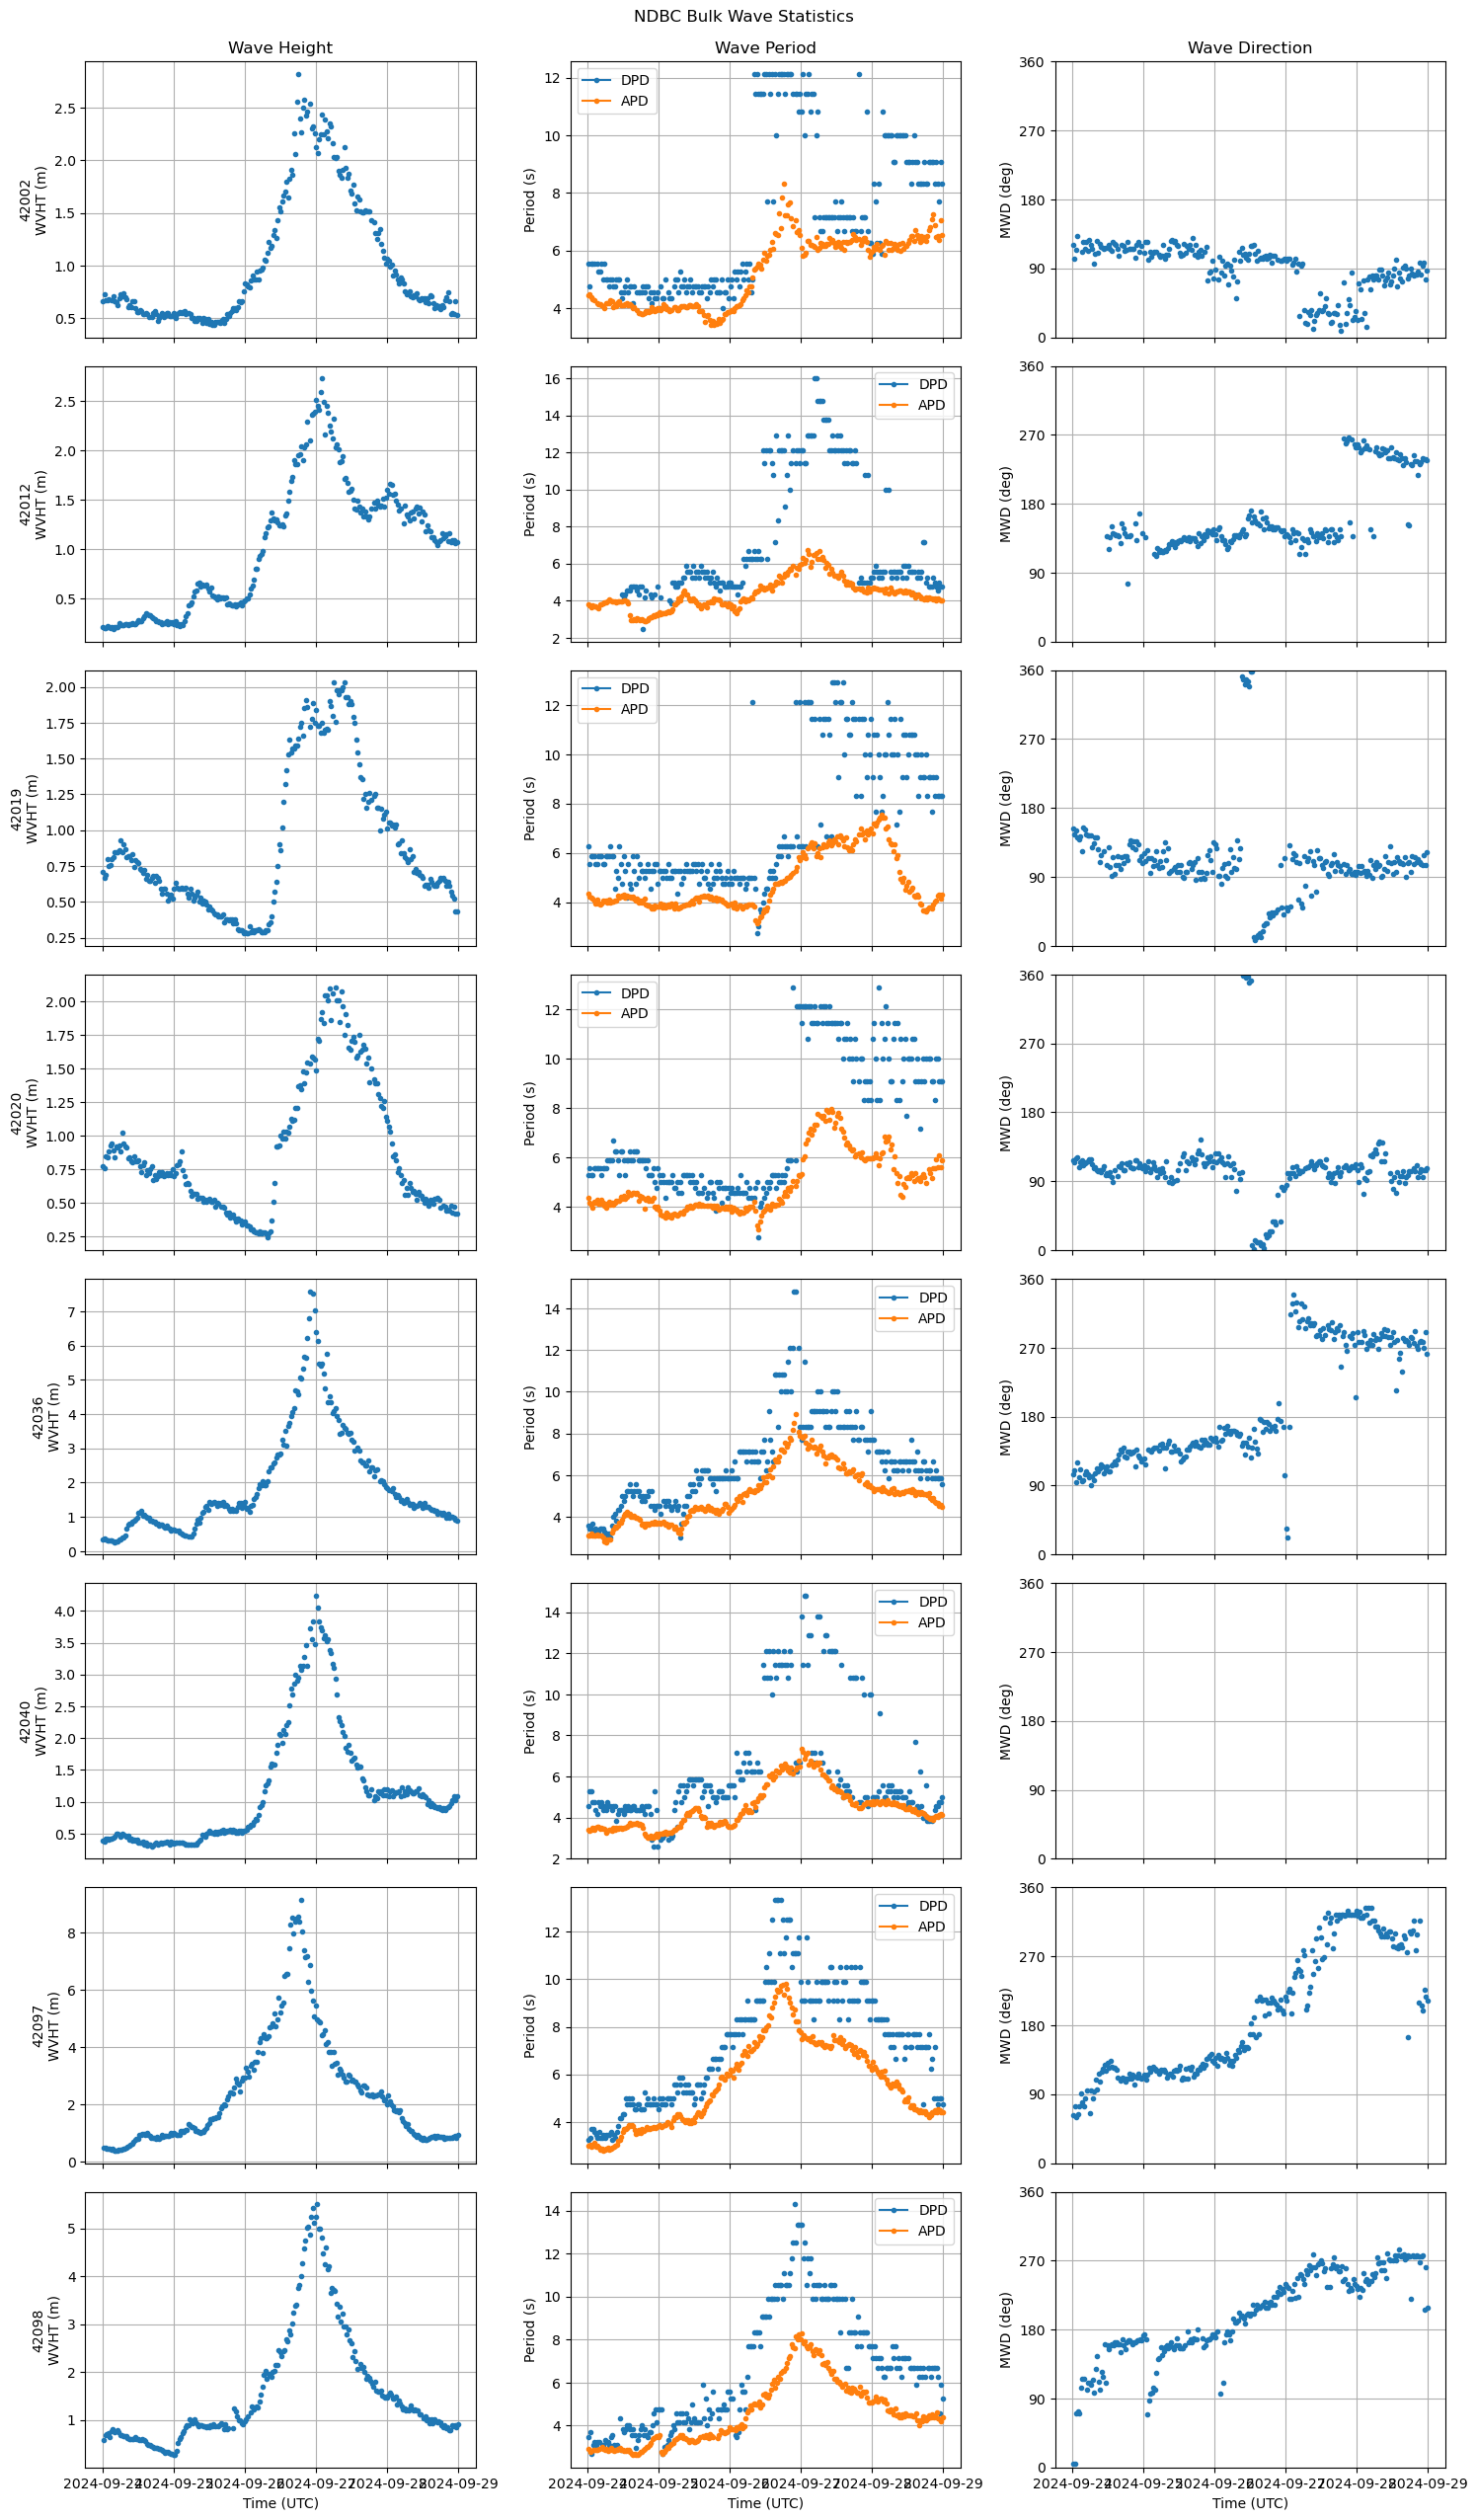

In [8]:
import io
import gzip
import requests
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt


# ============================================================
# USER SETTINGS
# ============================================================

BUOYS = [
    "42001",
    "42002",
    "42003",
    "42012",
    "42019",
    "42020",
    "42036",
    "42039",
    "42040",
    "42097",
    "42098",
]

START = "2024-09-24"
END   = "2024-09-28"
YEAR  = 2024

OUT_NC = "ndbc_20240924_20240928.nc"


# ============================================================
# NDBC DOWNLOAD / PARSE
# ============================================================

def _parse_ndbc_stdmet_text(text):
    """
    Parse one NDBC historical stdmet text file into a DataFrame.
    """
    lines = text.splitlines()
    lines = [ln.strip() for ln in lines if ln.strip()]
    if not lines:
        raise ValueError("Empty file")

    header_line = lines[0].lstrip("#").strip()
    cols = header_line.split()

    data_start = 1
    if len(lines) > 1:
        second = lines[1].split()
        nonnumeric = 0
        for tok in second:
            try:
                float(tok)
            except Exception:
                nonnumeric += 1
        if len(second) == len(cols) and nonnumeric >= max(3, len(second) // 3):
            data_start = 2

    data_text = "\n".join(lines[data_start:])
    if not data_text.strip():
        return pd.DataFrame(columns=cols)

    df = pd.read_csv(
        io.StringIO(data_text),
        sep=r"\s+",
        names=cols,
        na_values=["MM", "999", "999.0", "9999", "99.0", "99.00", "99999", "999999"],
        engine="python",
    )

    year_col = None
    for candidate in ["YYYY", "#YYYY", "YY", "#YY"]:
        if candidate in df.columns:
            year_col = candidate
            break
    if year_col is None:
        raise ValueError(f"Could not find year column in: {list(df.columns)}")

    required = ["MM", "DD", "hh"]
    for c in required:
        if c not in df.columns:
            raise ValueError(f"Missing required time column: {c}")

    minute_col = "mm" if "mm" in df.columns else None

    year = df[year_col].astype(int).to_numpy()
    if "YY" in year_col:
        year = np.where(year < 100, 2000 + year, year)

    month = df["MM"].astype(int).to_numpy()
    day = df["DD"].astype(int).to_numpy()
    hour = df["hh"].astype(int).to_numpy()
    minute = df[minute_col].astype(int).to_numpy() if minute_col else np.zeros(len(df), dtype=int)

    dt = pd.to_datetime(
        {
            "year": year,
            "month": month,
            "day": day,
            "hour": hour,
            "minute": minute,
        },
        errors="coerce",
        utc=True,
    )

    df.insert(0, "time", dt)
    df = df.dropna(subset=["time"]).reset_index(drop=True)
    return df


def download_ndbc_stdmet_station_year(station, year=2024, timeout=60):
    """
    Download and parse one NDBC historical stdmet file.
    """
    url = f"https://www.ndbc.noaa.gov/data/historical/stdmet/{station}h{year}.txt.gz"
    r = requests.get(url, timeout=timeout)
    r.raise_for_status()

    with gzip.GzipFile(fileobj=io.BytesIO(r.content)) as gz:
        text = gz.read().decode("utf-8", errors="replace")

    df = _parse_ndbc_stdmet_text(text)
    df["station"] = station
    return df


def subset_date_range_inclusive(df, start, end, time_col="time"):
    """
    Inclusive UTC date filter.
    """
    start_ts = pd.Timestamp(start, tz="UTC")
    end_ts = pd.Timestamp(end, tz="UTC") + pd.Timedelta(days=1) - pd.Timedelta(microseconds=1)
    return df.loc[(df[time_col] >= start_ts) & (df[time_col] <= end_ts)].copy()


def download_ndbc_bulk_stats(buoys, start, end, year=2024):
    per_buoy = {}

    for buoy in buoys:
        try:
            df = download_ndbc_stdmet_station_year(buoy, year=year)
            df = subset_date_range_inclusive(df, start=start, end=end)
            per_buoy[buoy] = df
            print(f"{buoy}: {len(df)} records")
        except Exception as e:
            print(f"{buoy}: FAILED -> {e}")
            per_buoy[buoy] = pd.DataFrame()

    combined = pd.concat(
        [df for df in per_buoy.values() if len(df) > 0],
        ignore_index=True,
        sort=False,
    ) if any(len(df) > 0 for df in per_buoy.values()) else pd.DataFrame()

    if len(combined) > 0:
        combined = combined.sort_values(["station", "time"]).reset_index(drop=True)

    return combined, per_buoy


# ============================================================
# SAVE TO NETCDF
# ============================================================

def build_ndbc_xarray(df, buoys):
    """
    Convert combined NDBC dataframe to xarray Dataset with dims:
      time, station

    Variables saved if present:
      WVHT, DPD, APD, MWD
    """
    if len(df) == 0:
        raise ValueError("Input dataframe is empty")

    df = df.copy()

    # Convert to timezone-naive datetime64[ns] for xarray/netcdf
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert(None)

    time = np.sort(df["time"].dropna().unique()).astype("datetime64[ns]")
    stations = [b for b in buoys if b in df["station"].unique()]
    ntime = len(time)
    nsta = len(stations)

    ds = xr.Dataset(
        coords={
            "time": ("time", time),
            "station": np.arange(nsta),
            "station_id": ("station", np.array(stations, dtype="U8")),
        }
    )

    var_map = {
        "WVHT": ("wave_height", "m"),
        "DPD":  ("dominant_period", "s"),
        "APD":  ("average_period", "s"),
        "MWD":  ("mean_wave_direction", "deg"),
    }

    time_index = pd.Index(time)
    station_index = {sta: i for i, sta in enumerate(stations)}

    for src_name, (out_name, units) in var_map.items():
        arr = np.full((ntime, nsta), np.nan, dtype=np.float32)

        if src_name in df.columns:
            for sta, g in df.groupby("station"):
                if sta not in station_index:
                    continue

                j = station_index[sta]
                gg = (
                    g[["time", src_name]]
                    .dropna()
                    .drop_duplicates(subset="time")
                    .sort_values("time")
                )
                if len(gg) == 0:
                    continue

                it = time_index.get_indexer(gg["time"].to_numpy().astype("datetime64[ns]"))
                good = it >= 0
                arr[it[good], j] = gg[src_name].to_numpy(dtype=np.float32)[good]

        ds[out_name] = (("time", "station"), arr)
        ds[out_name].attrs["units"] = units
        ds[out_name].attrs["source_name"] = src_name

    return ds


def save_ndbc_to_netcdf(df, buoys, out_nc):
    ds = build_ndbc_xarray(df, buoys)
    ds.to_netcdf(out_nc)
    return ds

# ============================================================
# PLOTTING
# ============================================================

def stations_with_wave_data(ds):
    """
    Return station indices with at least one finite wave value.
    """
    keep = []
    for i in range(ds.sizes["station"]):
        ok = False
        for v in ["wave_height", "dominant_period", "average_period", "mean_wave_direction"]:
            if v in ds and np.isfinite(ds[v].isel(station=i).values).any():
                ok = True
                break
        if ok:
            keep.append(i)
    return keep


def plot_ndbc_wave_multipanel(ds):
    """
    Multi-panel plot:
      one row per buoy with wave data,
      columns = wave height, period, direction
    """
    keep = stations_with_wave_data(ds)
    if len(keep) == 0:
        raise ValueError("No buoys with wave data found in dataset")

    nrows = len(keep)
    fig, axs = plt.subplots(
        nrows=nrows,
        ncols=3,
        figsize=(15, 3.2 * nrows),
        sharex=True,
        squeeze=False,
    )

    t = ds["time"].values

    for row, i in enumerate(keep):
        sta = str(ds["station_id"].isel(station=i).values)

        # Height
        ax = axs[row, 0]
        if "wave_height" in ds:
            ax.plot(t, ds["wave_height"].isel(station=i), ".-")
        ax.set_ylabel(f"{sta}\nWVHT (m)")
        ax.grid(True)

        # Period
        ax = axs[row, 1]
        has_legend = False
        if "dominant_period" in ds:
            y = ds["dominant_period"].isel(station=i).values
            if np.isfinite(y).any():
                ax.plot(t, y, ".-", label="DPD")
                has_legend = True
        if "average_period" in ds:
            y = ds["average_period"].isel(station=i).values
            if np.isfinite(y).any():
                ax.plot(t, y, ".-", label="APD")
                has_legend = True
        ax.set_ylabel("Period (s)")
        ax.grid(True)
        if has_legend:
            ax.legend()

        # Direction
        ax = axs[row, 2]
        if "mean_wave_direction" in ds:
            ax.plot(t, ds["mean_wave_direction"].isel(station=i), ".-")
        ax.set_ylabel("MWD (deg)")
        ax.set_ylim(0, 360)
        ax.set_yticks([0, 90, 180, 270, 360])
        ax.grid(True)

    axs[0, 0].set_title("Wave Height")
    axs[0, 1].set_title("Wave Period")
    axs[0, 2].set_title("Wave Direction")

    for ax in axs[-1, :]:
        ax.set_xlabel("Time (UTC)")

    fig.suptitle("NDBC Bulk Wave Statistics", y=0.995)
    fig.tight_layout()
    return fig, axs


# ============================================================
# RUN: DOWNLOAD AND SAVE
# ============================================================

df_ndbc, ndbc_by_buoy = download_ndbc_bulk_stats(
    BUOYS,
    start=START,
    end=END,
    year=YEAR,
)

print()
print(df_ndbc.groupby("station").size() if len(df_ndbc) else "No data returned")
print()

ds_ndbc = save_ndbc_to_netcdf(df_ndbc, BUOYS, OUT_NC)
print(ds_ndbc)
print(f"\nSaved: {OUT_NC}")


# ============================================================
# RUN: READ NETCDF AND PLOT
# ============================================================

ds_plot = xr.open_dataset(OUT_NC)
fig, axs = plot_ndbc_wave_multipanel(ds_plot)
plt.show()
